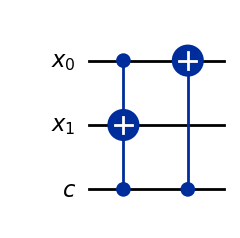

In [1]:
from qiskit import QuantumCircuit, QuantumRegister

pos_qbits = QuantumRegister(2, name="x")
coin_qbit = QuantumRegister(1, name="c")

qc = QuantumCircuit(pos_qbits, coin_qbit)

# increment
qc.ccx(coin_qbit[0], pos_qbits[0], pos_qbits[1])
qc.cx(coin_qbit[0], pos_qbits[0])

qc.draw("mpl")

In [2]:
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit

for c in [0, 1]:
    for x_0, x_1 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        init_qc = QuantumCircuit(pos_qbits, coin_qbit)

        if c == 1:
            init_qc.x(coin_qbit[0])
        if x_0:
            init_qc.x(pos_qbits[0])
        if x_1:
            init_qc.x(pos_qbits[1])

        qc_test = init_qc.compose(qc)

        state = Statevector.from_instruction(qc_test)
        state_dict = state.probabilities_dict()

        in_state = f"|{x_1}{x_0} {c}>"
        out_state = " + ".join(
            f"{prob:.2f}|{state[1:3]} {state[0]}>" for state, prob in state_dict.items()
        )
        print(f"{in_state} -> {out_state}")

|00 0> -> 1.00|00 0>
|10 0> -> 1.00|10 0>
|01 0> -> 1.00|01 0>
|11 0> -> 1.00|11 0>
|00 1> -> 1.00|01 1>
|10 1> -> 1.00|11 1>
|01 1> -> 1.00|10 1>
|11 1> -> 1.00|00 1>


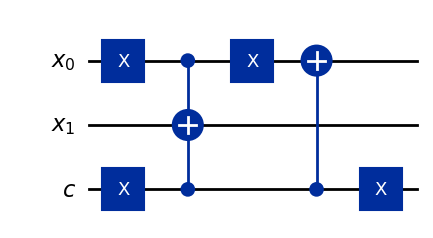

In [3]:
from qiskit import QuantumCircuit, QuantumRegister

pos_qbits = QuantumRegister(2, name="x")
coin_qbit = QuantumRegister(1, name="c")

qc = QuantumCircuit(pos_qbits, coin_qbit)

# decrement
qc.x([coin_qbit[0], pos_qbits[0]])
qc.ccx(coin_qbit[0], pos_qbits[0], pos_qbits[1])
qc.x(pos_qbits[0])
qc.cx(coin_qbit[0], pos_qbits[0])
qc.x(coin_qbit[0])

qc.draw("mpl")

In [4]:
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit

for c in [0, 1]:
    for x_0, x_1 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        init_qc = QuantumCircuit(pos_qbits, coin_qbit)

        if c == 1:
            init_qc.x(coin_qbit[0])
        if x_0:
            init_qc.x(pos_qbits[0])
        if x_1:
            init_qc.x(pos_qbits[1])

        qc_test = init_qc.compose(qc)

        state = Statevector.from_instruction(qc_test)
        state_dict = state.probabilities_dict()

        in_state = f"|{x_1}{x_0} {c}>"
        out_state = " + ".join(
            f"{prob:.2f}|{state[1:3]} {state[0]}>" for state, prob in state_dict.items()
        )
        print(f"{in_state} -> {out_state}")

|00 0> -> 1.00|11 0>
|10 0> -> 1.00|01 0>
|01 0> -> 1.00|00 0>
|11 0> -> 1.00|10 0>
|00 1> -> 1.00|00 1>
|10 1> -> 1.00|10 1>
|01 1> -> 1.00|01 1>
|11 1> -> 1.00|11 1>


In [5]:
def random_walk_step(qc, pos_qbits, coin_qbit):
    qc.h(coin_qbit[0])
    qc.barrier()

    # increment
    qc.ccx(coin_qbit[0], pos_qbits[0], pos_qbits[1])
    qc.cx(coin_qbit[0], pos_qbits[0])
    qc.barrier()

    # decrement
    qc.x([coin_qbit[0], pos_qbits[0]])
    qc.ccx(coin_qbit[0], pos_qbits[0], pos_qbits[1])
    qc.x(pos_qbits[0])
    qc.cx(coin_qbit[0], pos_qbits[0])
    qc.x(coin_qbit[0])
    qc.barrier()

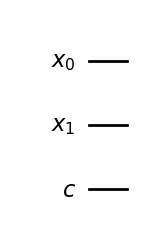

After step 0:
  1.00|00>


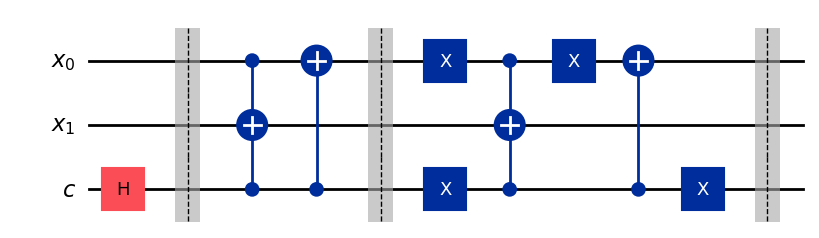

After step 1:
  0.50|01>
  0.50|11>


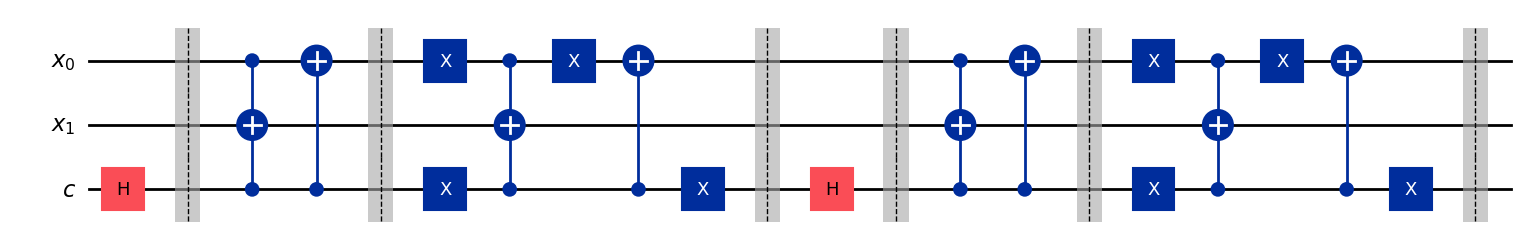

After step 2:
  0.50|00>
  0.50|10>


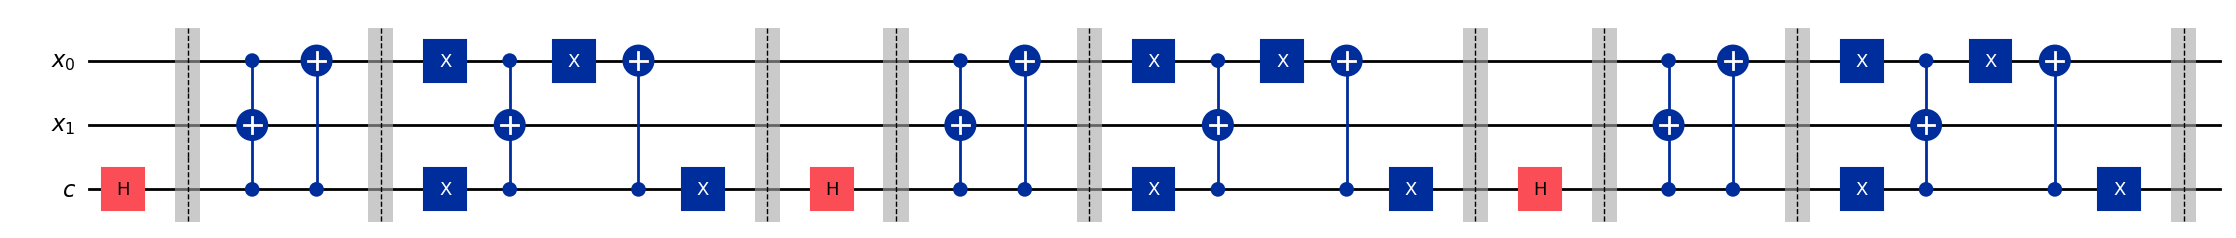

After step 3:
  1.00|11>


In [6]:
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit, QuantumRegister

steps = 3

pos_qbits = QuantumRegister(2, name="x")
coin_qbit = QuantumRegister(1, name="c")

qc = QuantumCircuit(pos_qbits, coin_qbit)

for step in range(steps + 1):
    display(qc.draw("mpl", fold=-1))
    
    state = Statevector.from_instruction(qc)
    state_dict = state.probabilities_dict()

    print(f"After step {step}:")
    for x_0, x_1 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        prob = state_dict.get(f"0{x_1}{x_0}", 0) + state_dict.get(f"1{x_1}{x_0}", 0)
        if prob >= 0.01:
            print(f"  {prob:.2f}|{x_1}{x_0}>") 
    
    random_walk_step(qc, pos_qbits, coin_qbit)

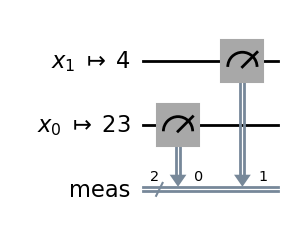

After step 0:


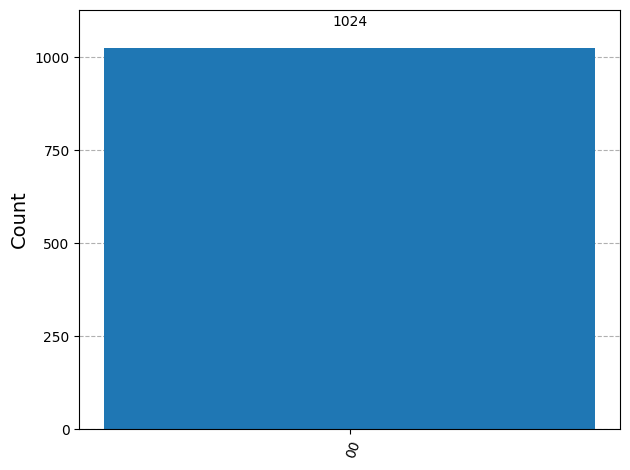

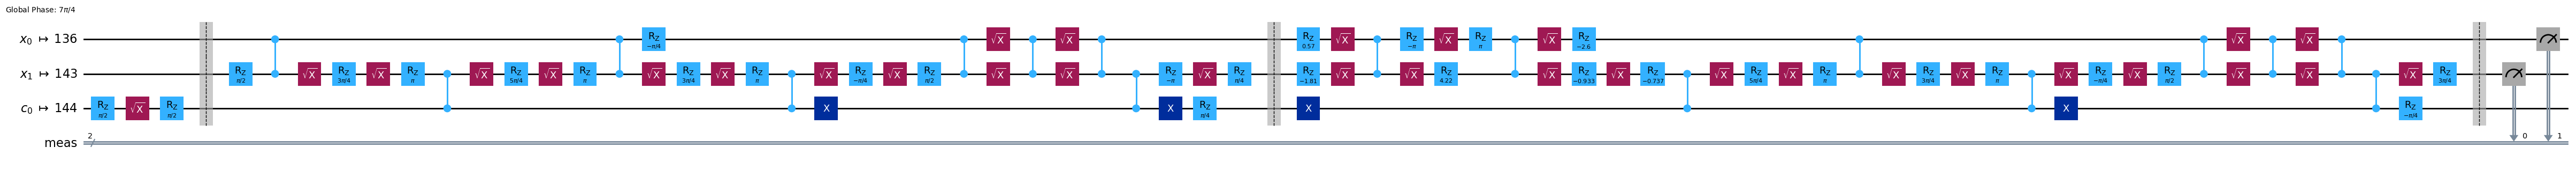

After step 1:


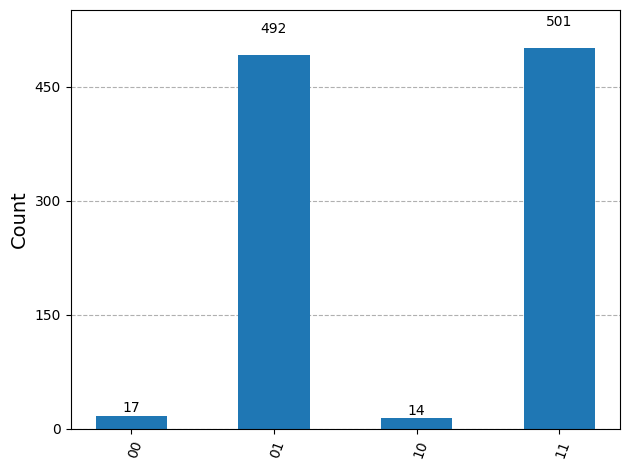

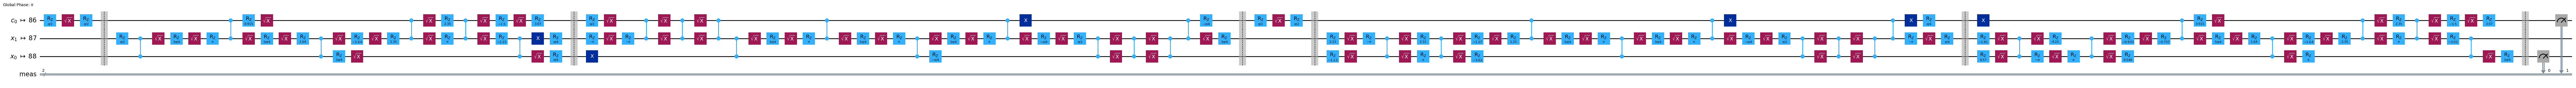

After step 2:


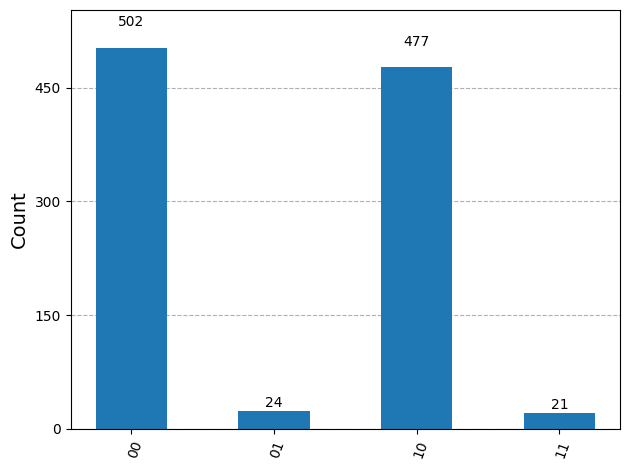



After step 3:


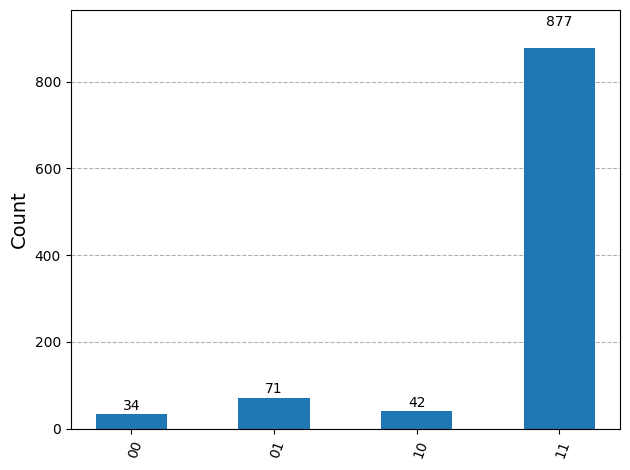

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.transpiler import generate_preset_pass_manager

steps = 3

pos_qbits = QuantumRegister(2, name="x")
coin_qbit = QuantumRegister(1, name="c")
c_bits = ClassicalRegister(2, name="meas")

qc = QuantumCircuit(pos_qbits, coin_qbit, c_bits)

backend = FakeFez()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

for step in range(steps + 1):
    qc_meas = qc.copy()
    qc_meas.measure(pos_qbits, c_bits)
    
    isa_circuit = pm.run(qc_meas)
    
    display(isa_circuit.draw("mpl", fold=-1))
    
    result = backend.run(isa_circuit, shots=1024).result()
    counts = result.get_counts()

    print(f"After step {step}:")
    display(plot_histogram(counts))
    
    random_walk_step(qc, pos_qbits, coin_qbit)
